In [4]:
import utility_functions as utils
import GLM
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
import numpy.matlib
sns.set_theme()

# Estimating coupling filter from neuron 1 to neuron 2

## Creating ground truth coupling filters and history filters

In [52]:
nt = 1000 # Say there are 1000 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
ntrial = 2000 # 5000 trials in total
Npop = 10 # ten neurons in each population
time_line = np.arange(nt)
log_lambda_baseline = np.log(0.05) # the baseline firing rate is 0.05 spikes/ms or 50 spikes/s
log_lambda_stimulus = 1* np.exp(-((time_line-300)/100)**2) # stimulus drives the firing rate higher around t=200ms. 
# We assume stimulus is the same for every trial. 

log_lambda_neuron1 = log_lambda_baseline + log_lambda_stimulus
lambda_neuron1 = np.exp(log_lambda_neuron1)
spike_neuron1 = np.random.poisson(lam=np.matlib.repmat(lambda_neuron1[:,np.newaxis],1,ntrial), size=None)


Text(0.5, 1.0, 'ground truth inhomo baseline')

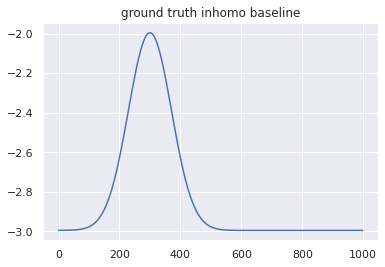

In [53]:
plt.plot(log_lambda_baseline+log_lambda_stimulus)
plt.title('ground truth inhomo baseline')

Text(0.5, 1.0, 'ground truth coupling$')

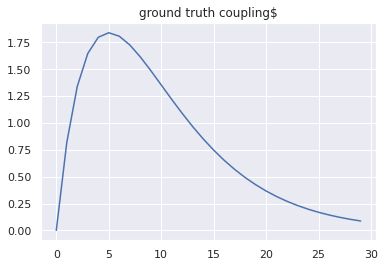

In [47]:
coupling_length = 30
time_line_coupling = np.arange(coupling_length)
ground_truth_coupling_filter = time_line_coupling*np.exp(-time_line_coupling/5)
plt.plot(ground_truth_coupling_filter)
plt.title('ground truth coupling$')

Text(0.5, 1.0, 'ground truth history')

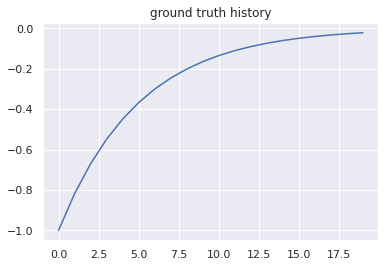

In [69]:
history_length = 20
time_line_history = np.arange(history_length)
ground_truth_history = - np.exp(-time_line_history/5)
# ground_truth_history = -100*np.ones_like(time_line_history)
plt.plot(ground_truth_history)
plt.title('ground truth history')

## Simulation

In [70]:
baseline_mat = np.vstack((log_lambda_baseline + log_lambda_stimulus, log_lambda_baseline + 0.5*log_lambda_stimulus)).T
coupling_mat = np.zeros((len(ground_truth_coupling_filter), 2,2))
coupling_mat[:,0,1] = np.flip(ground_truth_coupling_filter)
coupling_mat[:,1,0] = np.flip(ground_truth_coupling_filter)
history_list = [ground_truth_history for i in range(2)] 
nneuron_list = [10, 10]

pop_spikes, log_firing_rate_pop_level = GLM.simulate_individual_history(baseline_mat, 
                                                                        coupling_mat, 
                                                                        history_list, 
                                                                        nneuron_list=nneuron_list)

Text(0.5, 1.0, 'log firing rate of an example trial')

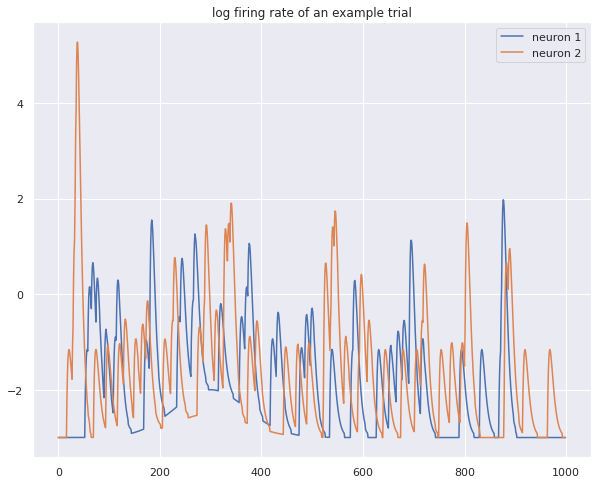

In [71]:
plt.subplots(figsize=(10,8))
plt.plot(log_firing_rate_pop_level[:,0], label='neuron 1')
plt.plot(log_firing_rate_pop_level[:,1], label='neuron 2')
plt.legend()
plt.title('log firing rate of an example trial')

# Fit GLM